# 08 — Cross-Attention

Pair as query attends to frozen setwise hidden states (N² × 32). All N² pairs.

**Input**: `models/setwise/best_model.pt` (frozen), features + glyph data
**Output**: `data/processed/models/cross_attention/*`


In [1]:
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger("kern")

_cwd = Path.cwd().resolve()
if (_cwd / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / "pyproject.toml").exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = _cwd
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FEATURE_DIR = DATA_PROCESSED / "features"
GLYPH_DIR = DATA_PROCESSED / "glyphs"
MODEL_DIR = DATA_PROCESSED / "models" / "cross_attention"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

LATIN_52 = "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
NUM_CLASSES = 52
FEATURE_DIM = 512
INPUT_DIM = FEATURE_DIM * 2 + NUM_CLASSES * 2  # 1128

D_MODEL = 32
NHEAD = 2
NUM_LAYERS = 1
QUERY_DIM = 64
KEY_DIM = 64

BATCH_SIZE = 64
LEARNING_RATE = 1e-4
MAX_EPOCHS = 100
EARLY_STOP_PATIENCE = 20
RANDOM_SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
log.info("Device: %s", DEVICE)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

SETWISE_BEST_MODEL = DATA_PROCESSED / "models" / "setwise" / "best_model.pt"


2026-07-27 15:45:54,171 | INFO | Device: cuda


In [2]:
catalog = pd.read_csv(DATA_PROCESSED / "fonts_catalog.csv")
feat_manifest = pd.read_csv(DATA_PROCESSED / "features_manifest.csv")
ok_stems = [s for s in feat_manifest[feat_manifest["status"] == "ok"]["stem"] if s in set(catalog["stem"])]
unique_stems = sorted(ok_stems)
log.info("Fonts with features: %d", len(unique_stems))

features_cache = {}
pair_dist_lookup = {}
glyph_names_cache = {}
for stem in tqdm(unique_stems, desc="Loading"):
    fz = np.load(FEATURE_DIR / f"{stem}.npz")
    features_cache[stem] = fz["features"]
    gz = np.load(GLYPH_DIR / f"{stem}.npz")
    glyph_names_cache[stem] = list(gz["glyph_names"])
    left, right, dists = gz["pair_left"], gz["pair_right"], gz["pair_distances"]
    lookup = {}
    for i in range(len(left)):
        lookup[(int(left[i]), int(right[i]))] = float(dists[i])
    pair_dist_lookup[stem] = lookup

total_mb = sum(a.nbytes for a in features_cache.values()) / 1e6
log.info("Features loaded: %.0f MB", total_mb)

stem_family = {}
for _, row in catalog[catalog["stem"].isin(unique_stems)].iterrows():
    stem_family[row["stem"]] = row["family"]

stem_specs = []
for stem in unique_stems:
    N = len(glyph_names_cache[stem])
    family = stem_family.get(stem, "unknown")
    stem_specs.append((stem, family, N))

all_families = sorted(set(f for _, f, _ in stem_specs))
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(all_families)

n = len(all_families)
n_train = int(n * 0.8)
n_val = int(n * 0.1)
train_families = set(all_families[:n_train])
val_families = set(all_families[n_train:n_train + n_val])
test_families = set(all_families[n_train + n_val:])

train_specs = [s for s in stem_specs if s[1] in train_families]
val_specs = [s for s in stem_specs if s[1] in val_families]
test_specs = [s for s in stem_specs if s[1] in test_families]
log.info("Families: %d train / %d val / %d test", len(train_families), len(val_families), len(test_families))

# Frozen setwise: precompute hidden states (norm output, N² × D_MODEL per font)
class SetwiseModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.input_proj = nn.Linear(FEATURE_DIM * 2, D_MODEL)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=NHEAD, batch_first=True,
            dim_feedforward=D_MODEL * 4, activation="relu",
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=NUM_LAYERS)
        self.norm = nn.LayerNorm(D_MODEL)

    def forward(self, x, mask=None):
        x = self.input_proj(x)
        x = self.transformer(x, src_key_padding_mask=mask)
        return self.norm(x)

sw_model = SetwiseModel().to(DEVICE)
sw_model.load_state_dict(torch.load(SETWISE_BEST_MODEL, weights_only=True, map_location=DEVICE), strict=False)
sw_model.eval()
log.info("Frozen setwise model loaded")

sw_hidden_cache = {}
for stem in tqdm(unique_stems, desc="Precomputing SW hidden"):
    feat = features_cache[stem]
    N = feat.shape[0]
    tokens = np.empty((N * N, FEATURE_DIM * 2), dtype=np.float32)
    idx = 0
    for i in range(N):
        fi = feat[i]
        for j in range(N):
            tokens[idx, :FEATURE_DIM] = fi
            tokens[idx, FEATURE_DIM:] = feat[j]
            idx += 1
    t = torch.from_numpy(tokens).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        hidden = sw_model(t, None)
    sw_hidden_cache[stem] = hidden.squeeze(0).cpu()
del sw_model
if DEVICE == "cuda": torch.cuda.empty_cache()
log.info("SW hidden states ready: %d fonts", len(sw_hidden_cache))


2026-07-27 15:46:05,728 | INFO | Fonts with features: 7263


Loading:   0%|          | 0/7263 [00:00<?, ?it/s]

2026-07-27 15:48:18,845 | INFO | Features loaded: 773 MB
2026-07-27 15:48:19,027 | INFO | Families: 1488 train / 186 val / 187 test
2026-07-27 15:48:20,586 | INFO | Frozen setwise model loaded


Precomputing SW hidden:   0%|          | 0/7263 [00:00<?, ?it/s]

2026-07-27 15:49:25,559 | INFO | SW hidden states ready: 7263 fonts


In [3]:
_char_to_idx = {c: i for i, c in enumerate(LATIN_52)}

class CrossAttentionPairwiseDataset(Dataset):
    def __init__(self, specs):
        self.stems = [s[0] for s in specs]
        self.Ns = [s[2] for s in specs]
        self._offsets = np.zeros(len(specs), dtype=np.int64)
        cum = 0
        for i, n in enumerate(self.Ns):
            self._offsets[i] = cum
            cum += n * n
        self._total = cum

    def __len__(self):
        return self._total

    def __getitem__(self, idx):
        stem_i = int(np.searchsorted(self._offsets, idx, side='right') - 1)
        stem = self.stems[stem_i]
        N = self.Ns[stem_i]
        local = idx - int(self._offsets[stem_i])
        li = local // N
        ri = local % N

        names = glyph_names_cache[stem]
        g1, g2 = names[li], names[ri]
        feat = features_cache[stem]
        f1 = torch.from_numpy(feat[li])
        f2 = torch.from_numpy(feat[ri])

        ci1 = _char_to_idx.get(g1)
        ci2 = _char_to_idx.get(g2)
        target = pair_dist_lookup[stem][(ci1, ci2)]

        oh1 = torch.zeros(NUM_CLASSES)
        oh2 = torch.zeros(NUM_CLASSES)
        if ci1 is not None: oh1[ci1] = 1.0
        if ci2 is not None: oh2[ci2] = 1.0

        pair = torch.cat([f1, f2, oh1, oh2])
        hidden = sw_hidden_cache[stem]
        return pair, hidden, torch.tensor(target, dtype=torch.float32)


def collate_cross_attention(batch):
    pairs = torch.stack([x[0] for x in batch])
    hidden = torch.stack([x[1] for x in batch])
    targets = torch.tensor([x[2] for x in batch])
    return pairs, hidden, targets


train_ds = CrossAttentionPairwiseDataset(train_specs)
val_ds = CrossAttentionPairwiseDataset(val_specs)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, collate_fn=collate_cross_attention)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, collate_fn=collate_cross_attention)
log.info("DataLoaders ready — %d train pairs", len(train_ds))


2026-07-27 15:49:25,579 | INFO | DataLoaders ready — 15569632 train pairs


In [4]:
class PairwiseEncoder(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=256, output_dim=QUERY_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)


class CrossAttentionModel(nn.Module):
    def __init__(self, pair_dim=INPUT_DIM, kv_dim=D_MODEL):
        super().__init__()
        self.encoder = PairwiseEncoder(pair_dim, QUERY_DIM)
        self.q_proj = nn.Linear(QUERY_DIM, KEY_DIM)
        self.k_proj = nn.Linear(kv_dim, KEY_DIM)
        self.v_proj = nn.Linear(kv_dim, KEY_DIM)
        self.head = nn.Sequential(
            nn.Linear(QUERY_DIM + KEY_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, 1),
        )
        self.scale = KEY_DIM ** 0.5

    def forward(self, pair, hidden):
        query = self.encoder(pair)
        Q = self.q_proj(query).unsqueeze(1)
        K = self.k_proj(hidden)
        V = self.v_proj(hidden)
        attn = torch.softmax(Q @ K.transpose(1, 2) / self.scale, dim=-1)
        context = (attn @ V).squeeze(1)
        fused = torch.cat([query, context], dim=1)
        return self.head(fused).squeeze(-1)


model = CrossAttentionModel().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
log.info("Model parameters: %d", n_params)


2026-07-27 15:49:25,691 | INFO | Model parameters: 122241


In [5]:
CHECKPOINT_PATH = MODEL_DIR / "checkpoint.pt"
BEST_MODEL_PATH = MODEL_DIR / "best_model.pt"
HISTORY_PATH = MODEL_DIR / "training_history.csv"

def run_epoch(loader, model, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total = 0.0, 0
    desc = "Train" if is_train else "Eval"
    for pair, hidden, y in tqdm(loader, desc=desc, leave=False):
        pair = pair.to(DEVICE)
        hidden = hidden.to(DEVICE)
        y = y.to(DEVICE)
        if is_train:
            optimizer.zero_grad()
        out = model(pair, hidden)
        loss = criterion(out, y)
        if is_train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(y)
        total += len(y)
    return total_loss / total

start_epoch = 1
history = []
best_val_loss = float("inf")
patience_counter = 0

if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, weights_only=False, map_location="cpu")
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    start_epoch = ckpt["epoch"] + 1
    best_val_loss = ckpt["best_val_loss"]
    patience_counter = ckpt["patience_counter"]
    history = ckpt.get("history", [])
    log.info("Resumed from epoch %d", ckpt["epoch"])
else:
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    log.info("Starting fresh. LR=%.0e, batch=%d", LEARNING_RATE, BATCH_SIZE)

criterion = nn.L1Loss()

for epoch in range(start_epoch, MAX_EPOCHS + 1):
    train_loss = run_epoch(train_loader, model, criterion, optimizer)
    val_loss = run_epoch(val_loader, model, criterion)
    history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
    log.info("Epoch %3d | train_loss=%.4f val_loss=%.4f", epoch, train_loss, val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        log.info("  -> Saved best model")
    else:
        patience_counter += 1

    torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(), "best_val_loss": best_val_loss,
        "patience_counter": patience_counter, "history": history}, CHECKPOINT_PATH)

    if patience_counter >= EARLY_STOP_PATIENCE:
        log.info("Early stopping at epoch %d", epoch)
        break

pd.DataFrame(history).to_csv(HISTORY_PATH, index=False)
log.info("Done.")

if CHECKPOINT_PATH.exists():
    CHECKPOINT_PATH.unlink()


2026-07-27 15:49:35,575 | INFO | Starting fresh. LR=1e-04, batch=64


Train:   0%|          | 0/243276 [00:00<?, ?it/s]

Eval:   0%|          | 0/30378 [00:00<?, ?it/s]

2026-07-27 16:50:04,506 | INFO | Epoch   1 | train_loss=4.3250 val_loss=4.4972
2026-07-27 16:50:04,522 | INFO |   -> Saved best model


Train:   0%|          | 0/243276 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/30378 [00:00<?, ?it/s]

2026-07-30 05:43:09,110 | INFO | Epoch  61 | train_loss=2.1767 val_loss=3.7650


Train:   0%|          | 0/243276 [00:00<?, ?it/s]

Eval:   0%|          | 0/30378 [00:00<?, ?it/s]

2026-07-30 06:44:45,169 | INFO | Epoch  62 | train_loss=2.1709 val_loss=3.8002
2026-07-30 06:44:45,180 | INFO | Early stopping at epoch 62
2026-07-30 06:44:45,456 | INFO | Done.


In [6]:
model.load_state_dict(torch.load(BEST_MODEL_PATH, weights_only=True, map_location=DEVICE))
model.eval()

all_preds, all_targets, all_stems = [], [], []
with torch.no_grad():
    for stem, _, N in tqdm(test_specs, desc="Testing per-font"):
        names = glyph_names_cache[stem]
        feat = features_cache[stem]
        hidden = sw_hidden_cache[stem].to(DEVICE)

        for li in range(N):
            g1 = names[li]
            ci1 = _char_to_idx.get(g1)
            oh1 = torch.zeros(NUM_CLASSES)
            if ci1 is not None: oh1[ci1] = 1.0
            f1 = torch.from_numpy(feat[li])
            for ri in range(N):
                g2 = names[ri]
                ci2 = _char_to_idx.get(g2)
                oh2 = torch.zeros(NUM_CLASSES)
                if ci2 is not None: oh2[ci2] = 1.0
                f2 = torch.from_numpy(feat[ri])
                pair = torch.cat([f1, f2, oh1, oh2]).unsqueeze(0).to(DEVICE)
                h = hidden.unsqueeze(0)
                pred = model(pair, h).item()
                target = pair_dist_lookup[stem][(ci1, ci2)]
                all_preds.append(pred)
                all_targets.append(target)
                all_stems.append(stem)

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
test_mae = np.abs(all_preds - all_targets).mean()
log.info("Test MAE flat: %.4f px", test_mae)

test_font_mae = []
for stem_spec in test_specs:
    s = stem_spec[0]
    mask = np.array([s == st for st in all_stems])
    if mask.sum() > 0:
        mae_s = np.abs(all_preds[mask] - all_targets[mask]).mean()
        test_font_mae.append({"stem": s, "mae": mae_s})

df_font_mae = pd.DataFrame(test_font_mae)
df_font_mae.to_csv(MODEL_DIR / "test_font_mae.csv", index=False)
pd.DataFrame({"test_mae_flat": [test_mae]}).to_csv(MODEL_DIR / "test_mae_flat.csv", index=False)
log.info("Saved CSVs")


Testing per-font:   0%|          | 0/786 [00:00<?, ?it/s]

2026-07-30 07:05:48,354 | INFO | Test MAE flat: 4.1320 px
2026-07-30 07:07:46,722 | INFO | Saved CSVs


In [7]:
print("=" * 60)
print("CROSS-ATTENTION - RESULTS")
print("=" * 60)

hist = pd.read_csv(HISTORY_PATH)
ca_flat = pd.read_csv(MODEL_DIR / "test_mae_flat.csv")["test_mae_flat"].values[0]
print(f"\n  Epochs trained:   {len(hist)}")
print(f"  Best val MAE:     {hist['val_loss'].min():.4f} px")
print(f"  Test MAE flat:    {ca_flat:.4f} px")
print(f"\n  Per-font MAE:")
print(f"    mean:           {df_font_mae['mae'].mean():.4f} px")
print(f"    median:         {df_font_mae['mae'].median():.4f} px")
print(f"    std:            {df_font_mae['mae'].std():.4f} px")
print(f"    fonts < 7 px:   {(df_font_mae['mae'] < 7).sum()} / {len(df_font_mae)}")
print("\n" + "=" * 60)


CROSS-ATTENTION - RESULTS

  Epochs trained:   62
  Best val MAE:     3.7039 px
  Test MAE flat:    4.1320 px

  Per-font MAE:
    mean:           4.1320 px
    median:         3.3050 px
    std:            3.5494 px
    fonts < 7 px:   688 / 786



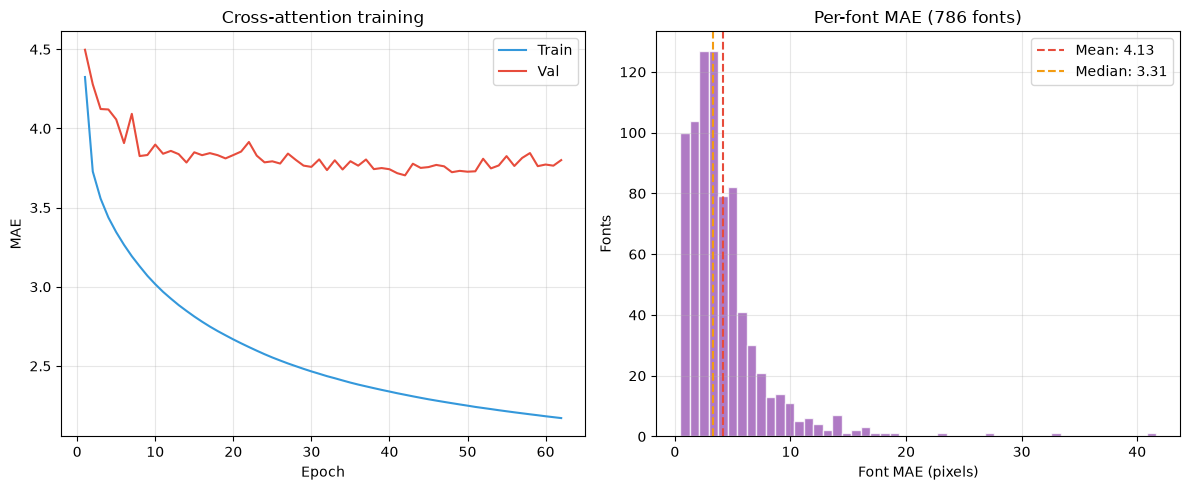

In [8]:
import matplotlib.pyplot as plt

hist = pd.read_csv(HISTORY_PATH)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(hist["epoch"], hist["train_loss"], label="Train", color="#3498db")
axes[0].plot(hist["epoch"], hist["val_loss"], label="Val", color="#e74c3c")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MAE")
axes[0].set_title("Cross-attention training")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(df_font_mae["mae"], bins=50, color="#9b59b6", edgecolor="white", alpha=0.8)
axes[1].axvline(df_font_mae["mae"].mean(), color="#e74c3c", linestyle="--", label=f"Mean: {df_font_mae['mae'].mean():.2f}")
axes[1].axvline(df_font_mae["mae"].median(), color="#f39c12", linestyle="--", label=f"Median: {df_font_mae['mae'].median():.2f}")
axes[1].set_xlabel("Font MAE (pixels)")
axes[1].set_ylabel("Fonts")
axes[1].set_title(f"Per-font MAE ({len(df_font_mae)} fonts)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
